<a href="https://colab.research.google.com/github/tegarbenayaa/UAS-KDKA/blob/main/KDKAkel6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MEMBACA DATASET
Jumlah Data Awal : 114000
Jumlah Data Setelah Cleaning : 113999

Melakukan Feature Engineering...
Jumlah Genre : 114

Data Train : 91199
Data Test  : 22800

Melatih Decision Tree untuk Feature Importance...

===== FEATURE IMPORTANCE =====
             Feature  Importance
0         popularity    0.290194
9       acousticness    0.130286
1        duration_ms    0.093083
3       danceability    0.090313
8        speechiness    0.068961
12           valence    0.061764
6           loudness    0.050068
13             tempo    0.044121
10  instrumentalness    0.036717
16    track_name_len    0.030844
15       num_artists    0.026523
4             energy    0.021210
17    album_name_len    0.019042
11          liveness    0.013006
2           explicit    0.011730
7               mode    0.008898
14    time_signature    0.001978
5                key    0.001261


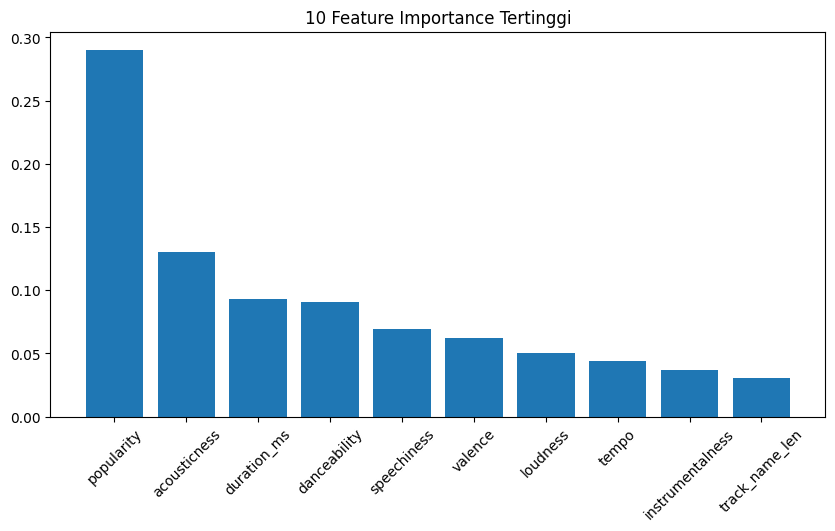


Top Features:
['popularity', 'acousticness', 'duration_ms', 'danceability', 'speechiness', 'valence', 'loudness', 'tempo', 'instrumentalness', 'track_name_len']

Training KNN Euclidean...
Training KNN Manhattan...
Training KNN Minkowski...
Training Decision Tree...


HASIL PERBANDINGAN MODEL
           Model  Accuracy  Precision    Recall  F1-Score  Training Time (s)
1  KNN Manhattan  0.243158   0.253700  0.243158  0.238465           0.260022
0  KNN Euclidean  0.228640   0.237981  0.228640  0.224522           0.142015
2  KNN Minkowski  0.220307   0.228730  0.220307  0.215502           0.163689
3  Decision Tree  0.215439   0.216001  0.215439  0.194254           9.277633


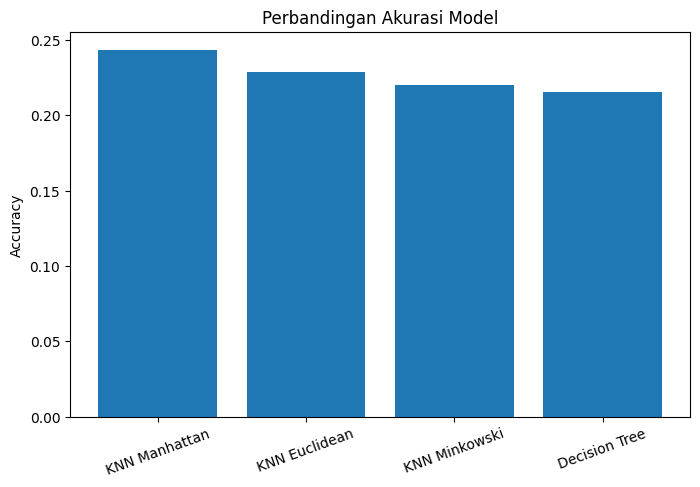

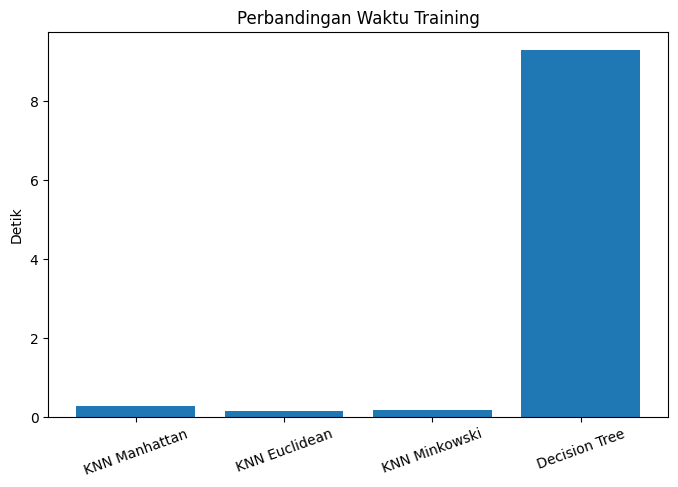


Model Terbaik : KNN Manhattan
Accuracy      : 24.32 %


<Figure size 1200x1200 with 0 Axes>

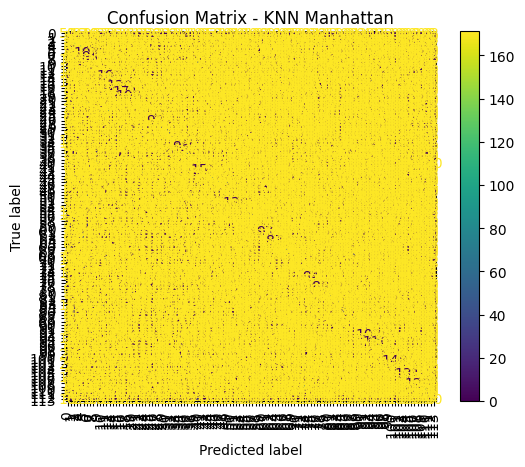

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)


class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None

class DecisionTreeClassifier:
    def __init__(self, max_depth=10, random_state=42):
        self.max_depth = max_depth
        self.random_state = random_state
        self.root = None
        self.feature_importances_ = None

    def fit(self, X, y):

        X_arr = np.array(X)
        y_arr = np.array(y)
        n_features = X_arr.shape[1]
        self.feature_importances_ = np.zeros(n_features)

        self.root = self._build_tree(X_arr, y_arr, depth=0)


        total_importance = np.sum(self.feature_importances_)
        if total_importance > 0:
            self.feature_importances_ /= total_importance

    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0
        counts = np.bincount(y)
        probabilities = counts / m
        return 1.0 - np.sum(probabilities ** 2)

    def _best_split(self, X, y):
        m, n = X.shape
        if m <= 1:
            return None, None, 0

        best_gini_gain = -1
        split_idx, split_thresh = None, None
        current_gini = self._gini(y)


        for feat_idx in range(n):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)


            if len(thresholds) > 30:
                np.random.seed(self.random_state)
                thresholds = np.random.choice(thresholds, size=30, replace=False)

            for threshold in thresholds:
                left_mask = X_column <= threshold
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                y_left, y_right = y[left_mask], y[right_mask]


                m_l, m_r = len(y_left), len(y_right)
                gini_left = self._gini(y_left)
                gini_right = self._gini(y_right)
                child_gini = (m_l / m) * gini_left + (m_r / m) * gini_right


                gini_gain = current_gini - child_gini

                if gini_gain > best_gini_gain:
                    best_gini_gain = gini_gain
                    split_idx = feat_idx
                    split_thresh = threshold

        return split_idx, split_thresh, best_gini_gain

    def _build_tree(self, X, y, depth):
        num_labels = len(np.unique(y))


        if depth >= self.max_depth or num_labels == 1 or len(y) < 2:
            leaf_value = np.bincount(y).argmax() if len(y) > 0 else 0
            return Node(value=leaf_value)


        feat_idx, threshold, gain = self._best_split(X, y)

        if gain <= 0 or feat_idx is None:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)


        self.feature_importances_[feat_idx] += gain * len(y)


        left_mask = X[:, feat_idx] <= threshold
        right_mask = ~left_mask

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(feature=feat_idx, threshold=threshold, left=left_child, right=right_child)

    def predict(self, X):
        X_arr = np.array(X)
        return np.array([self._traverse_tree(x, self.root) for x in X_arr])

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)



print("=" * 60)
print("MEMBACA DATASET")
print("=" * 60)

df = pd.read_csv("spotify-tracks-dataset-detailed.csv")
print("Jumlah Data Awal :", len(df))




df = df.dropna()
print("Jumlah Data Setelah Cleaning :", len(df))




print("\nMelakukan Feature Engineering...")

df["explicit"] = df["explicit"].astype(int)
df["num_artists"] = df["artists"].astype(str).apply(lambda x: len(x.split(";")))
df["track_name_len"] = df["track_name"].astype(str).apply(len)
df["album_name_len"] = df["album_name"].astype(str).apply(len)




fitur = [
    "popularity",
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "num_artists",
    "track_name_len",
    "album_name_len",
]

X = df[fitur]




encoder = LabelEncoder()
y = encoder.fit_transform(df["track_genre"])
print("Jumlah Genre :", len(np.unique(y)))




X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nData Train :", len(X_train))
print("Data Test  :", len(X_test))




print("\nMelatih Decision Tree untuk Feature Importance...")

dt_feature = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_feature.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": fitur,
    "Importance": dt_feature.feature_importances_,
}).sort_values(by="Importance", ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(importance)




plt.figure(figsize=(10, 5))
plt.bar(importance["Feature"][:10], importance["Importance"][:10])
plt.title("10 Feature Importance Tertinggi")
plt.xticks(rotation=45)
plt.show()




top_features = importance.head(10)["Feature"].tolist()
print("\nTop Features:")
print(top_features)

X_train = X_train[top_features]
X_test = X_test[top_features]




scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




hasil = []
best_model_name = None
best_prediction = None
best_accuracy = 0


def evaluasi_model(nama_model, model, X_train, X_test, y_train, y_test):
    global best_model_name, best_prediction, best_accuracy

    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    training_time = end - start

    hasil.append([nama_model, acc, precision, recall, f1, training_time])

    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = nama_model
        best_prediction = y_pred




print("\nTraining KNN Euclidean...")
knn_euc = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
evaluasi_model("KNN Euclidean", knn_euc, X_train_scaled, X_test_scaled, y_train, y_test)




print("Training KNN Manhattan...")
knn_man = KNeighborsClassifier(n_neighbors=5, metric="manhattan")
evaluasi_model("KNN Manhattan", knn_man, X_train_scaled, X_test_scaled, y_train, y_test)




print("Training KNN Minkowski...")
knn_min = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=3)
evaluasi_model("KNN Minkowski", knn_min, X_train_scaled, X_test_scaled, y_train, y_test)




print("Training Decision Tree...")
dt_final = DecisionTreeClassifier(random_state=42, max_depth=10)
evaluasi_model("Decision Tree", dt_final, X_train, X_test, y_train, y_test)




hasil_df = pd.DataFrame(
    hasil,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "Training Time (s)"],
).sort_values(by="Accuracy", ascending=False)

print("\n")
print("=" * 80)
print("HASIL PERBANDINGAN MODEL")
print("=" * 80)
print(hasil_df)
print("=" * 80)




plt.figure(figsize=(8, 5))
plt.bar(hasil_df["Model"], hasil_df["Accuracy"])
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()





plt.figure(figsize=(8, 5))
plt.bar(hasil_df["Model"], hasil_df["Training Time (s)"])
plt.title("Perbandingan Waktu Training")
plt.ylabel("Detik")
plt.xticks(rotation=20)
plt.show()




print("\nModel Terbaik :", best_model_name)
print("Accuracy      :", round(best_accuracy * 100, 2), "%")

plt.figure(figsize=(12, 12))
ConfusionMatrixDisplay.from_predictions(y_test, best_prediction, xticks_rotation="vertical")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()